In [25]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import pymc
from magnus import NSFeas

In [26]:
# Helpers
def theta_nominal():
    T_REF = 328.15
    k_1_ref = 8.84e-3 * 60 * 0.5 # 1/min
    k_2_ref = k_1_ref / 8
    theta_1 = k_1_ref * np.exp(E_1 / (R_GAS * T_REF))
    theta_2 = k_2_ref * np.exp(E_2 / (R_GAS * T_REF))

    return theta_1, theta_2

In [27]:
# Global Constants
E_1 = 48_000 # J/mol (activation energy first reaction)
E_2 = 55_000 # J/mol (activation energy second reaction)
R_GAS = 8.314 # J/K/mol
th_1, th_2 = theta_nominal()
BENZENE_FEED_CONC = 11.28e3 # mol/m3

In [28]:
# Calculation of arrhenius prefactors (T-dependent)

def compute_k(T_1, T_2):
    k_1_R1 = th_1 * np.exp(- E_1 / (R_GAS * T_1))
    k_2_R1 = th_2 * np.exp(- E_2 / (R_GAS * T_1))
    k_1_R2 = th_1 * np.exp(- E_1 / (R_GAS * T_2))
    k_2_R2 = th_2 * np.exp(- E_2 / (R_GAS * T_2))

    return (k_1_R1, k_2_R1), (k_1_R2, k_2_R2)

In [29]:
# Counters (for stat purposes only)
M1_counter = R1_counter = R2_counter = S1_counter = 0

In [30]:
# Mixer
def M1(rho, c_R, c_F):
    global M1_counter; M1_counter += 1
    c_A_R, c_B_R, c_C_R = c_R[0], c_R[1], c_R[2]
    c_A_F, c_B_F, c_C_F = c_F[0], c_F[1], c_F[2]
    c_A_alpha = rho * c_A_R + (1 - rho) * c_A_F
    c_B_alpha = rho * c_B_R + (1 - rho) * c_B_F
    c_C_alpha = rho * c_C_R + (1 - rho) * c_C_F

    return c_A_alpha, c_B_alpha, c_C_alpha

In [31]:
# CSTR1
def R1(c_alpha, k_R1, tau_1):
    global R1_counter; R1_counter += 1
    k_1_R1, k_2_R1 = k_R1[0], k_R1[1]
    c_A_alpha, c_B_alpha, c_C_alpha = c_alpha[0], c_alpha[1], c_alpha[2]

    c_A_R1 = c_A_alpha / (1 + k_1_R1 * tau_1)
    c_B_R1 = (c_B_alpha + k_1_R1 * c_A_R1 * tau_1) / (1 + k_2_R1 * tau_1)
    c_C_R1 = c_C_alpha + k_2_R1 * c_B_R1 * tau_1
    
    return  c_A_R1, c_B_R1, c_C_R1

In [32]:
# CSTR2
def R2(c_R1, k_R2, tau_2):
    global R2_counter; R2_counter += 1
    c_A_R1, c_B_R1, c_C_R1 = c_R1[0], c_R1[1], c_R1[2]
    k_1_R2, k_2_R2 = k_R2[0], k_R2[1]

    c_A_R2 = c_A_R1 / (1 + k_1_R2 * tau_2)
    c_B_R2 = (c_B_R1 + k_1_R2 * c_A_R2 * tau_2) / (1 + k_2_R2 * tau_2)
    c_C_R2 = c_C_R1 + k_2_R2 * c_B_R2 * tau_2

    return c_A_R2, c_B_R2, c_C_R2

In [33]:
# Splitter
def S1(c_R2):
    # NOTE: rho: recycle ratio, dens: density
    global S1_counter; S1_counter += 1
    c_A_R2, c_B_R2, c_C_R2 = c_R2[0], c_R2[1], c_R2[2]
    M_A, M_B, M_C = 78.11, 112.56, 147.00 # g/mol
    dens_A, dens_B, dens_C = 0.88e6, 1.11e6, 1.30e6 # g/m3
    s_A, s_B, s_C = 0.7, 0.35, 0.20 # these values are for illustration
    summands = [M_A / dens_A  * s_A * c_A_R2, M_B / dens_B  * s_B * c_B_R2, M_C / dens_C  * s_C * c_C_R2]
    rho = sum(summands)
    assert rho >= 0 and rho < 1
    c_A_R = s_A * c_A_R2 / rho
    c_B_R = s_B * c_B_R2 / rho
    c_C_R = s_C * c_C_R2 / rho

    return (c_A_R, c_B_R, c_C_R), rho

In [34]:
def get_informed_guess():
    """Make informed initial guess by finding nearest feasible configuration
    First value: is informed guess available (NONE if no feasible points found yet),
    Second value: rho_ig,
    Third value: c_R_ig
    TODO: implement this if fixed point iterations are slow
    """
    return None, None, None

In [35]:
def is_converged(c_R_real_guess, rho_real_guess):
    """Takes in tuples of real and guessed values for c_R 
    (recycle stream concentration), and rho (recycle ratio)
    and compares them."""
    (c_A_R_real, c_B_R_real, c_C_R_real), (c_A_R_guess, c_B_R_guess, c_C_R_guess) = c_R_real_guess
    rho_real, rho_guess = rho_real_guess
    real = np.array([c_A_R_real, c_B_R_real, c_C_R_real, rho_real])
    guess = np.array([c_A_R_guess, c_B_R_guess, c_C_R_guess, rho_guess])
    diff = np.abs(real - guess) # abs is safeguarding only
    diff_norm = diff / max((abs(real)).max(), 1e-8)
    max_vio = diff_norm.max()

    return max_vio < 1e-8

In [36]:
class SimResult:
    def __init__(self, converged, c_alpha, c_R1, c_R2, c_R, rho, c_F):
        self.converged = converged
        self.c_alpha = c_alpha
        self.c_R1 = c_R1
        self.c_R2 = c_R2
        self.c_R = c_R
        self.c_F = c_F
        self.rho = rho

In [37]:
# Simulate forward (to be called by Nested Sampler)
def sim_forward(T_1, tau_1, T_2, tau_2):
    it, MAX_ITER = 0, 1000
    c_F = BENZENE_FEED_CONC, 0, 0 # mol/m3 (pure benzene feed)
    # initial guesses (ig)
    inf_guess = get_informed_guess()
    rho_ig = 0.3 if not inf_guess[0] else inf_guess[1]
    c_R_ig = (5, 2, 1) if not inf_guess[0] else inf_guess[2]

    # k need fresh computatation at each configuration (T-dependent)
    k_R1, k_R2 = compute_k(T_1, T_2)

    while (it < MAX_ITER):
        it += 1
        c_alpha = M1(rho=rho_ig, c_R=c_R_ig, c_F=c_F)
        c_R1 = R1(c_alpha=c_alpha, k_R1=k_R1, tau_1=tau_1)
        c_R2 = R2(c_R1=c_R1, k_R2=k_R2, tau_2=tau_2)
        c_R, rho = S1(c_R2=c_R2)
        conv = is_converged((c_R, c_R_ig), (rho, rho_ig))
        if conv:
            # NOTE: return guess not result
            return SimResult(converged=True, c_alpha=c_alpha,
                             c_R1=c_R1, c_R2=c_R2,
                             c_R=c_R, c_F=c_F, rho=rho)

        # update to next tear iteration
        c_R_ig, rho_ig = c_R, rho

    # not converged within MAX_ITER
    return SimResult(False, None, None, None, None, None, None)

In [38]:
# Interface Adapter
def model(x):
    T_1, tau_1, T_2, tau_2 = x[0], x[1], x[2], x[3]
    sim_res = sim_forward(T_1=T_1, tau_1=tau_1, T_2=T_2, tau_2=tau_2)
    if not sim_res.converged:
        # return *something* guaranteed to be infeasible
        return [-1e-8, -1e-8, -1e-8, -1e-8, -1e-8, -1e-8]
    c_A_R1, c_B_R1, c_C_R1 = sim_res.c_R1[0], sim_res.c_R1[1], sim_res.c_R1[2] 
    c_A_R2, c_B_R2, c_C_R2 = sim_res.c_R2[0], sim_res.c_R2[1], sim_res.c_R2[2] 

    return [c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2]

In [39]:
# Nested Sampling of [T1, tau1, T2, tau2] space
DAG = pymc.FFGraph()
DAG.options.MAXTHREAD = 1

T_1, tau_1 = DAG.add_var('T_1'), DAG.add_var('tau_1')
T_2, tau_2 = DAG.add_var('T_2'), DAG.add_var('tau_2')

op = pymc.FFCustom()
op.set_D_eval(model)
# applying the operation adds nodes to DAG
outs = op(ndep=6, var=[T_1, tau_1, T_2, tau_2], uid=0)
c_A_R1, c_A_R2, c_B_R1, c_B_R2, c_C_R1, c_C_R2 = outs[0], outs[1], outs[2], outs[3], outs[4], outs[5]

In [40]:
# Setup nested sampler
NS = NSFeas()
NS.options.MAXTHREAD = 1           # Python callback + GIL: must be 1
NS.options.DISPLEVEL = 1           # console verbosity
NS.options.DISPITER  = 25          # rows per N iterations in table (cosmetic)
NS.options.NUMLIVE   = 8192        # #Live Points
NS.options.NUMPROP   = 256         # Proposals per iteration
NS.options.MAXITER   = 0           # iterate until complete (hard iteration limit else)

NS.set_dag(DAG)
# contols for variables and bounds
NS.set_control([T_1, tau_1, T_2, tau_2], [298.15, 2, 298.15, 2], [353.15, 30, 353.15, 30])
NS.set_constraint([c_C_R1 / (c_A_R1 + c_B_R1 + c_C_R1) - 0.05,
                   0.55 - c_B_R2 / (c_A_R2 + c_B_R2 + c_C_R2), 
                   0.70 - (1 - c_A_R2 / BENZENE_FEED_CONC)])
NS.setup()
NS.sample()
NS.stats.display()


** INITIALIZING LIVE POINTS (8192)      0.74 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.6639e-01   103        0     3.0000e-01
     25     3.1804e-01   180     4744     2.6720e-01
     50     2.1590e-01   267     7710     2.4853e-01
     75     1.6382e-01   348     9875     2.3574e-01
    100     1.3190e-01   438    11594     2.2605e-01
    125     1.1176e-01   522    13016     2.1834e-01
    150     9.5795e-02   614    14266     2.1177e-01
    175     8.4133e-02   707    15380     2.0609e-01
    200     7.4885e-02   795    16396     2.0104e-01
    225     6.7744e-02   889    17287     1.9672e-01
    250     6.1498e-02   988    18134     1.9269e-01
    275     5.6047e-02  1083    18908     1.8908e-01
    300     5.1609e-02  1186    19646     1.8571e-01
    325     4.5847e-02  1349    20577     1.8153e-01
    350     3.8940e-02  1563    21836     1.7604e-01
    375     3.3127e-02  1822    23070     1.7081

panel counts (rows = $\tau_2$ [min] high->low, cols = $\tau_1$ [min] low->high):
[[ 7074  2581  1779]
 [ 9265  3187  1980]
 [11098  4292  2316]]
sum of panels = 43572   total points = 43572


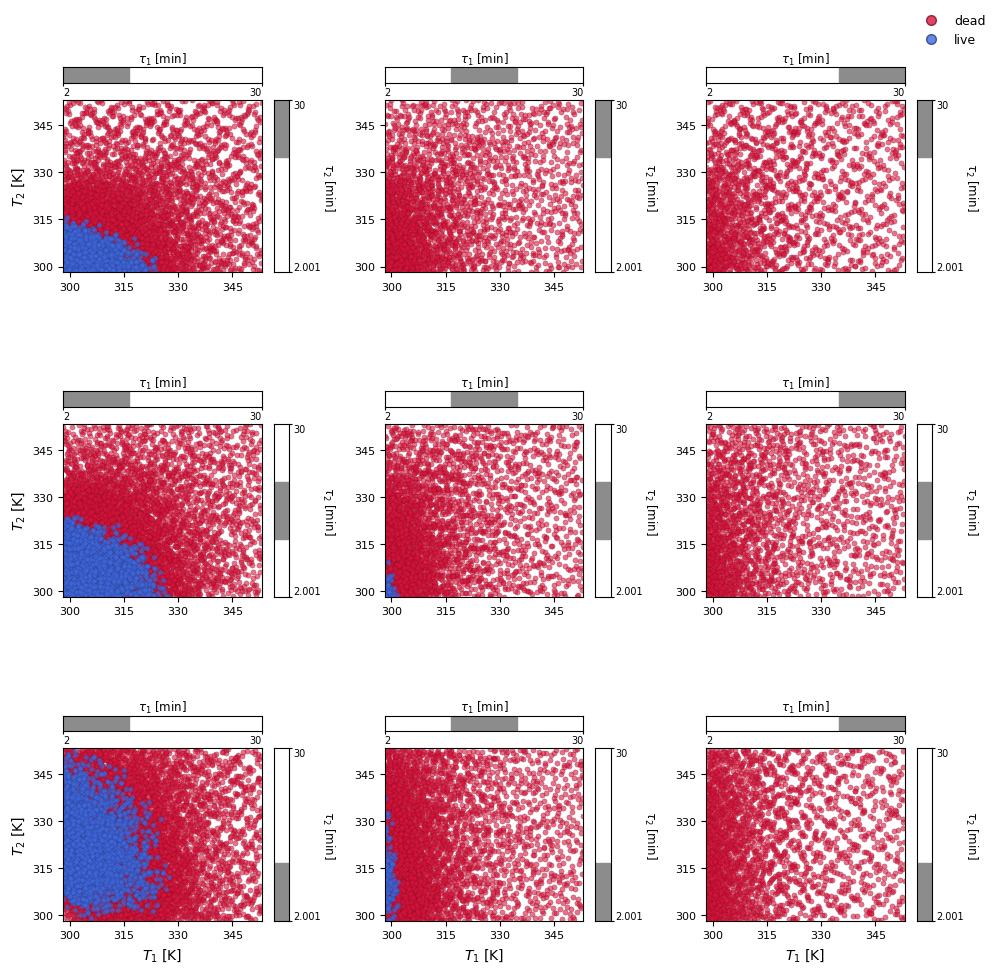

In [41]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "plots" / "tools"))
from trellis import trellis_plot #pyright:ignore

# NS.livepoints returns: (points[N, nu],  crit[N, 1],  prob[N, 1],  aux[N, 1])
live_pts, live_feas, *_ = NS.live_points
dead_pts, dead_feas, *_ = NS.dead_points

fig = trellis_plot(
    [dead_pts[:, 0], live_pts[:, 0]],   # T_1
    [dead_pts[:, 2], live_pts[:, 2]],   # T_2
    [dead_pts[:, 1], live_pts[:, 1]],   # tau_1
    [dead_pts[:, 3], live_pts[:, 3]],   # tau_2
    x_label="$T_1$ [K]",
    y_label=r"$T_2$ [K]",
    col_label=r"$\tau_1$ [min]",
    row_label=r"$\tau_2$ [min]",
    colors=["crimson", "royalblue"],
    labels=["dead", "live"],
)

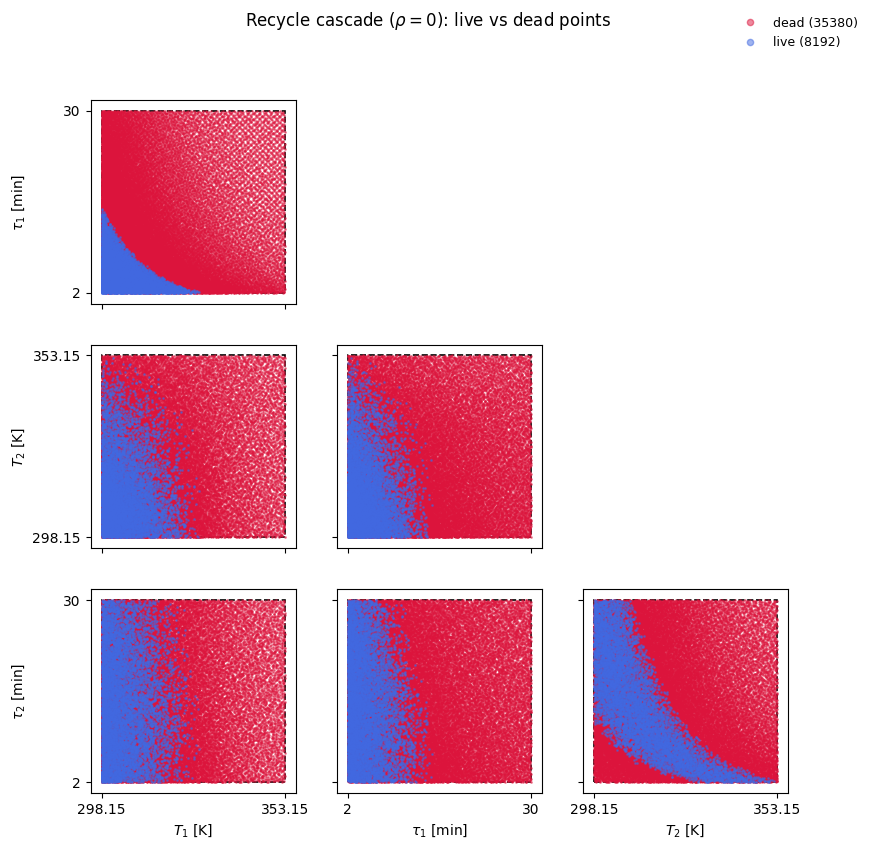

In [42]:
from corner import corner_plot

fig = corner_plot(
    [  # painter's order: dead below, live (feasible) on top
        dict(data=dead_pts, color="crimson", ms=2, alpha=0.5, label=f"dead ({len(dead_pts)})"),
        dict(data=live_pts, color="royalblue", ms=2, alpha=0.5, label=f"live ({len(live_pts)})"),
    ],
    labels=[r"$T_1$ [K]", r"$\tau_1$ [min]", r"$T_2$ [K]", r"$\tau_2$ [min]"],
    bounds=[(298.15, 353.15), (2, 30), (298.15, 353.15), (2, 30)],
    legend=True,
    title=r"Recycle cascade ($\rho = 0$): live vs dead points",
)

In [46]:
assert M1_counter == R1_counter == R2_counter == S1_counter and M1_counter != 0